# Diabetes Prediction using Logistic Regression and Neural Networks

This project focuses on predicting whether a patient has diabetes using medical attributes. We are using Logistic Regression, and deep learning models like Neural Networks to compare their performance.

In [1]:
import pandas as pd
import tensorflow as tf
from sklearn.model_selection import train_test_split
from sklearn.metrics import confusion_matrix,accuracy_score,precision_score,recall_score,f1_score,ConfusionMatrixDisplay,precision_recall_curve
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler,MinMaxScaler,RobustScaler
from sklearn.metrics import classification_report
from sklearn.decomposition import PCA
from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.callbacks import ReduceLROnPlateau
from sklearn.utils.class_weight import compute_class_weight
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import copy
from imblearn.over_sampling import SMOTE
from statsmodels.stats.outliers_influence import variance_inflation_factor

## Exploratory Data Analysis (EDA)

In [2]:
_health_data = pd.read_csv('./healthcare_dataset.csv')

In [3]:
_health_data.head()

,patient_id,age,bmi,exercise_hours_per_week,smoker,blood_pressure,diabetes
0,1,31,18.3,1.5,0,119.1,0
1,2,44,26.3,3.1,0,120.5,0
2,3,43,24.2,4.8,0,130.3,0
3,4,32,25.0,6.0,0,119.5,0
4,5,28,22.1,4.2,1,127.4,0


In [4]:
_health_data.shape


(6000, 7)

In [5]:
_health_data.describe()

,patient_id,age,bmi,exercise_hours_per_week,smoker,blood_pressure,diabetes
count,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000,6000.000000
mean,3000.500000,51.107333,25.995267,3.012800,0.307000,134.239733,0.090333
std,1732.195139,19.522722,4.960541,1.491802,0.461288,11.234260,0.286683
min,1.000000,18.000000,15.000000,0.000000,0.000000,94.000000,0.000000
25%,1500.750000,34.000000,22.500000,2.000000,0.000000,126.000000,0.000000
50%,3000.500000,51.000000,26.100000,3.000000,0.000000,134.200000,0.000000
75%,4500.250000,68.000000,29.400000,4.000000,1.000000,142.325000,0.000000
max,6000.000000,84.000000,44.900000,8.500000,1.000000,169.700000,1.000000


In [6]:
_health_data.dtypes

patient_id                   int64
age                          int64
bmi                        float64
exercise_hours_per_week    float64
smoker                       int64
blood_pressure             float64
diabetes                     int64
dtype: object

In [7]:
_health_data.isnull().sum()

patient_id                 0
age                        0
bmi                        0
exercise_hours_per_week    0
smoker                     0
blood_pressure             0
diabetes                   0
dtype: int64

In [8]:
_health_data['diabetes'].unique()

array([0, 1], dtype=int64)

### Feature Distributions

These plots illustrate how the values of different features are distributed across the dataset, helping to understand their spread, central tendency, and variability. Features show varied distributions age is near-uniform, BMI is slightly skewed and blood pressure is approximately normal, and exercise hours is right-skewed

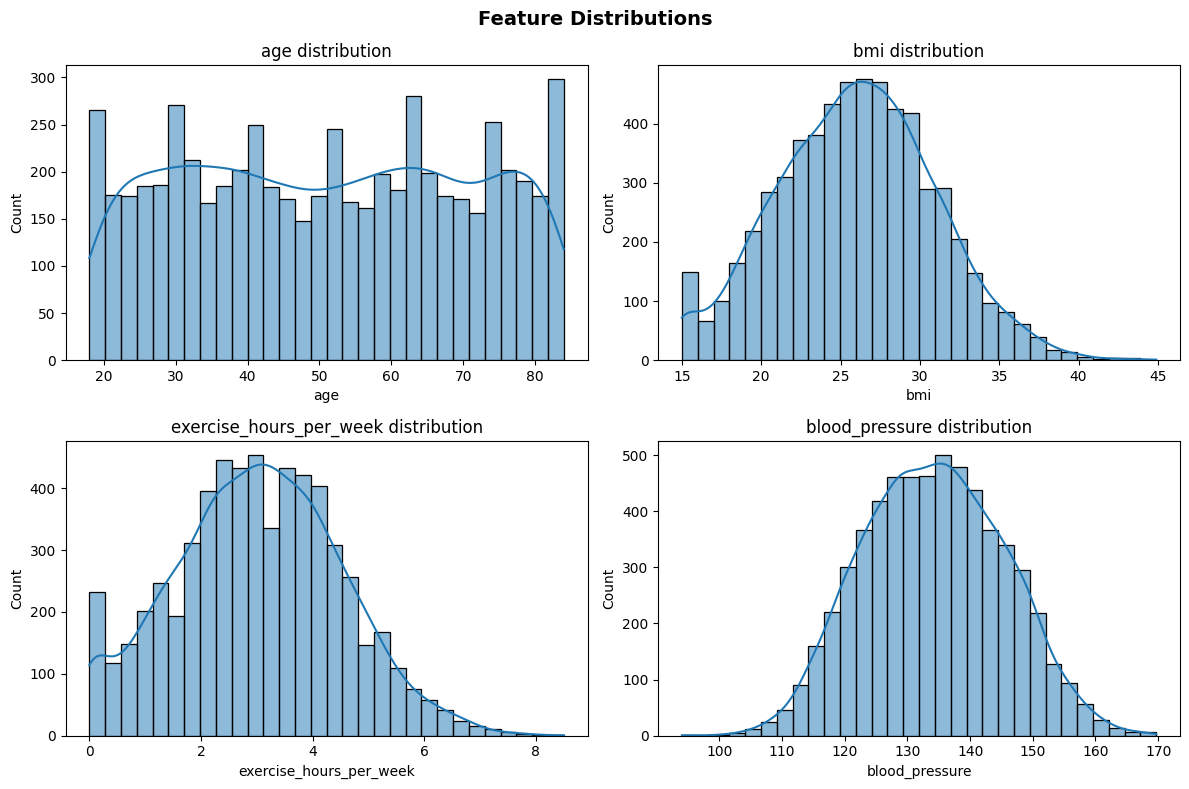

In [9]:
cols = ['age', 'bmi', 'exercise_hours_per_week', 'blood_pressure']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Feature Distributions', fontsize=14, fontweight='bold')

for i, col in enumerate(cols):
    ax = axes[i//2, i%2]
    sns.histplot(_health_data[col], bins=30, kde=True, ax=ax)
    ax.set_title(f'{col} distribution')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')

plt.tight_layout()
fig.savefig('feature_distributions_before_preprocessing.png', dpi=300, bbox_inches='tight')
plt.show()

### Smoker vs Diabetes

Diabetes prevalence is nearly identical between smokers and non-smokers, confirming that smoking has virtually no predictive relationship with diabetes

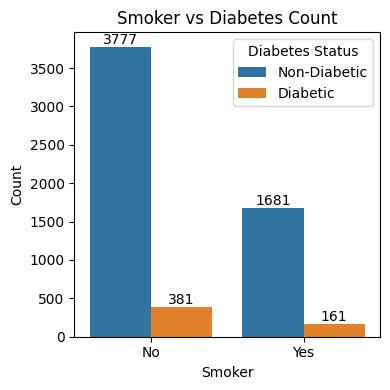

In [10]:
# counts = _health_data.groupby(['smoker', 'diabetes']).size()
_health_data_copy = _health_data.copy()
_health_data_copy['smoker'] = _health_data_copy['smoker'].map({0:'No', 1:'Yes'})
_health_data_copy['diabetes'] = _health_data_copy['diabetes'].map({0:'Non-Diabetic', 1:'Diabetic'})

fig, ax = plt.subplots(figsize=(4,4))

ax = sns.countplot(x='smoker', hue='diabetes', data=_health_data_copy)

for container in ax.containers:
    ax.bar_label(container)

ax.set_title('Smoker vs Diabetes Count')
ax.set_xlabel('Smoker')
ax.set_ylabel('Count')

ax.legend(title='Diabetes Status')

plt.tight_layout()
fig.savefig('.smoker_vs_diabetes_count.png', dpi=300, bbox_inches='tight')

plt.show()
# print("Smokers with diabetes:", counts.get((1,1), 0))
# print("Smokers without diabetes:", counts.get((1,0), 0))
# print("Non-smokers with diabetes:", counts.get((0,1), 0))
# print("Non-smokers without diabetes:", counts.get((0,0), 0))

### Age Vs Diabetes

Diabetic patients tend to be older compared to non-diabetics, suggesting age is a modest but the most meaningful predictor of diabetes

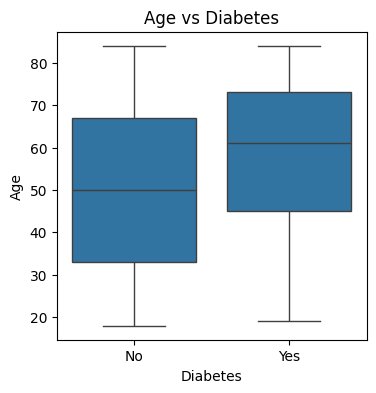

In [11]:
_health_data_copy = _health_data.copy()

_health_data_copy['diabetes'] = _health_data_copy['diabetes'].replace({0:'No',1:'Yes'})
plt.figure(figsize=(4,4))
sns.boxplot(x='diabetes', y='age', data=_health_data_copy)
plt.title('Age vs Diabetes')
plt.xlabel('Diabetes')
plt.ylabel('Age')
plt.savefig('age_vs_diabetes.png', dpi=300, bbox_inches='tight')
plt.show()

### Diabetes Vs BP

Diabetic patients show a marginally higher median blood pressure compared to non-diabetics, with a tighter IQR suggesting a weak but slight upward trend in BP with diabetes.

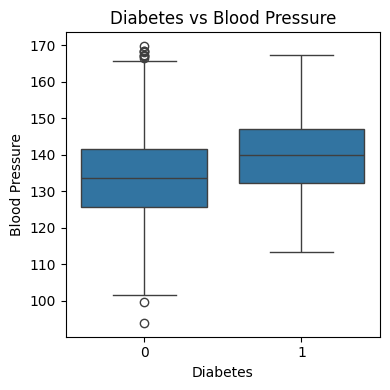

In [12]:
plt.figure(figsize=(4,4))

sns.boxplot(x='diabetes', y='blood_pressure', data=_health_data)

plt.title('Diabetes vs Blood Pressure')
plt.xlabel('Diabetes')
plt.ylabel('Blood Pressure')

plt.tight_layout()
plt.savefig('diabetes_vs_bp.png', dpi=300, bbox_inches='tight')

plt.show()

### Diabetes Vs BMI

Diabetic patients have a noticeably higher median BMI versus non-diabetics, making BMI the strongest visual separator between the two classes

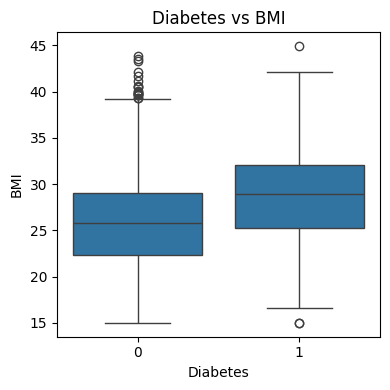

In [13]:
plt.figure(figsize=(4,4))

sns.boxplot(x='diabetes', y='bmi', data=_health_data)

plt.title('Diabetes vs BMI')
plt.xlabel('Diabetes')
plt.ylabel('BMI')

plt.tight_layout()
plt.savefig('diabetes_vs_bmi.png', dpi=300, bbox_inches='tight')

plt.show()

### overall feature analysis

Blood pressure dominates in scale, while exercise hours is the most compact and low-valued feature, highlighting the need for data preprocessing for outlier removal

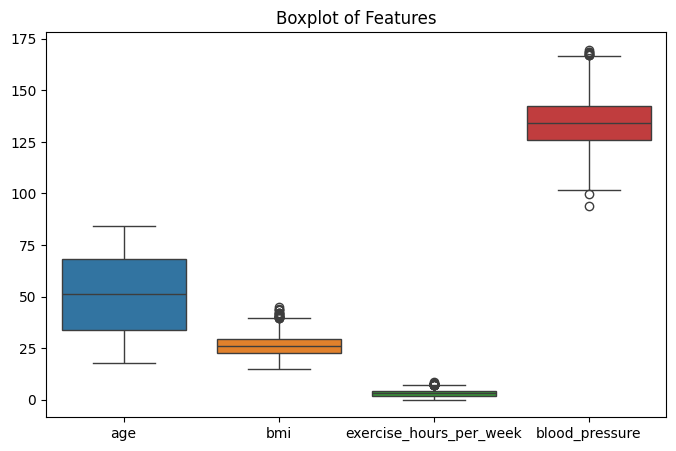

In [14]:
plt.figure(figsize=(8,5))
sns.boxplot(data=_health_data[['age','bmi','exercise_hours_per_week','blood_pressure']])

plt.title('Boxplot of Features')
plt.savefig('boxplot_features_before_preprocessing.png', dpi=300, bbox_inches='tight')

plt.show()

### The target class is heavily imbalanced with 9:1 ratio of non-diabetic to diabetic cases. Indicating that the dataset is imbalanced

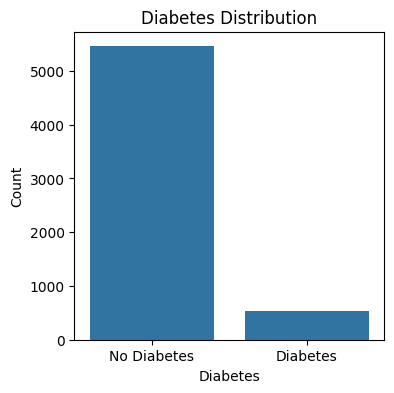

In [15]:
plt.figure(figsize=(4, 4))
sns.countplot(x='diabetes', data=_health_data)
plt.title('Diabetes Distribution')
plt.xlabel('Diabetes')
plt.ylabel('Count')
plt.xticks([0, 1], ['No Diabetes', 'Diabetes'])
plt.savefig('target_var_distribution.png', dpi=300, bbox_inches='tight')
plt.show()

### No feature correlates strongly with diabetes (max 0.17 for BMI), while the notable age–blood pressure (0.71) and smoker–blood pressure (0.43) inter-feature correlations reveal multicollinearity.

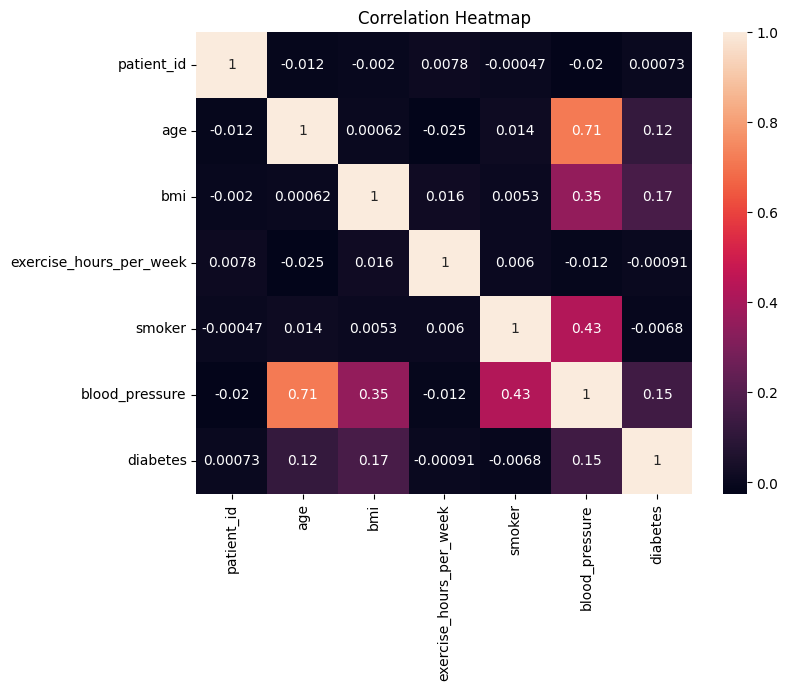

In [16]:
plt.figure(figsize=(8,6))
sns.heatmap(_health_data.corr(), annot=True)
plt.title('Correlation Heatmap')
plt.savefig('correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

### Data Preprocessing

Here we are removing the outliers 

In [17]:
_numeric_cols = ['age', 'bmi', 'exercise_hours_per_week', 'blood_pressure']
_original_rows = len(_health_data)

for col in _numeric_cols:
    if col == 'bmi':
        _health_data = _health_data[_health_data['bmi'] <= 39]
    else:
        _Q1 = _health_data[col].quantile(0.25)
        _Q3 = _health_data[col].quantile(0.75)
        _IQR = _Q3 - _Q1
        _low  = _Q1 - 1.5 * _IQR
        _high = _Q3 + 1.5 * _IQR
        _health_data = _health_data[(_health_data[col] >= _low) & (_health_data[col] <= _high)]

_removed = _original_rows - len(_health_data)
_pct_removed = (_removed / _original_rows) * 100

print(f"Original rows : {_original_rows}")
print(f"Remaining rows: {len(_health_data)}")
print(f"Removed : {_removed} ({_pct_removed:.2f}%)")

if _pct_removed < 10:
    print("OK outliers removed are below 10% of the dataset")
else:
    print("WARNING more than 10% of data was removed, review thresholds")

Original rows : 6000
Remaining rows: 5943
Removed : 57 (0.95%)
OK outliers removed are below 10% of the dataset


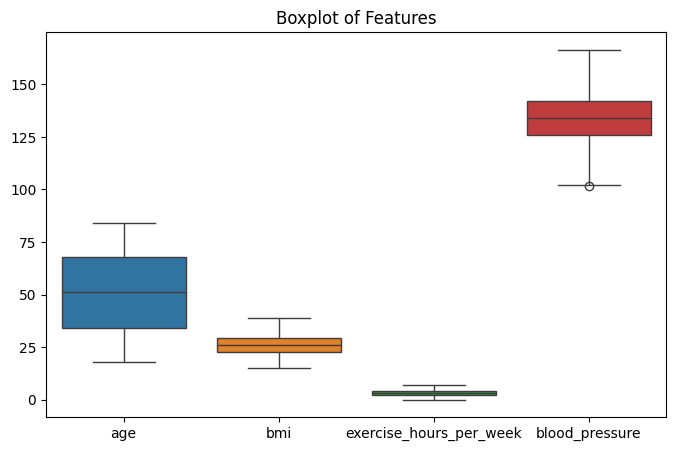

In [18]:
fig, ax = plt.subplots(figsize=(8,5))
sns.boxplot(data=_health_data[['age','bmi','exercise_hours_per_week','blood_pressure']], ax=ax)
ax.set_title('Boxplot of Features')
fig.savefig('boxplot_features_after_preprocess.png', dpi=300, bbox_inches='tight')
plt.show()

After removing the outliers we can see that the fetaure distributions are now balanced, compared to the raw data everything looks balanced with bmi having a mild skew

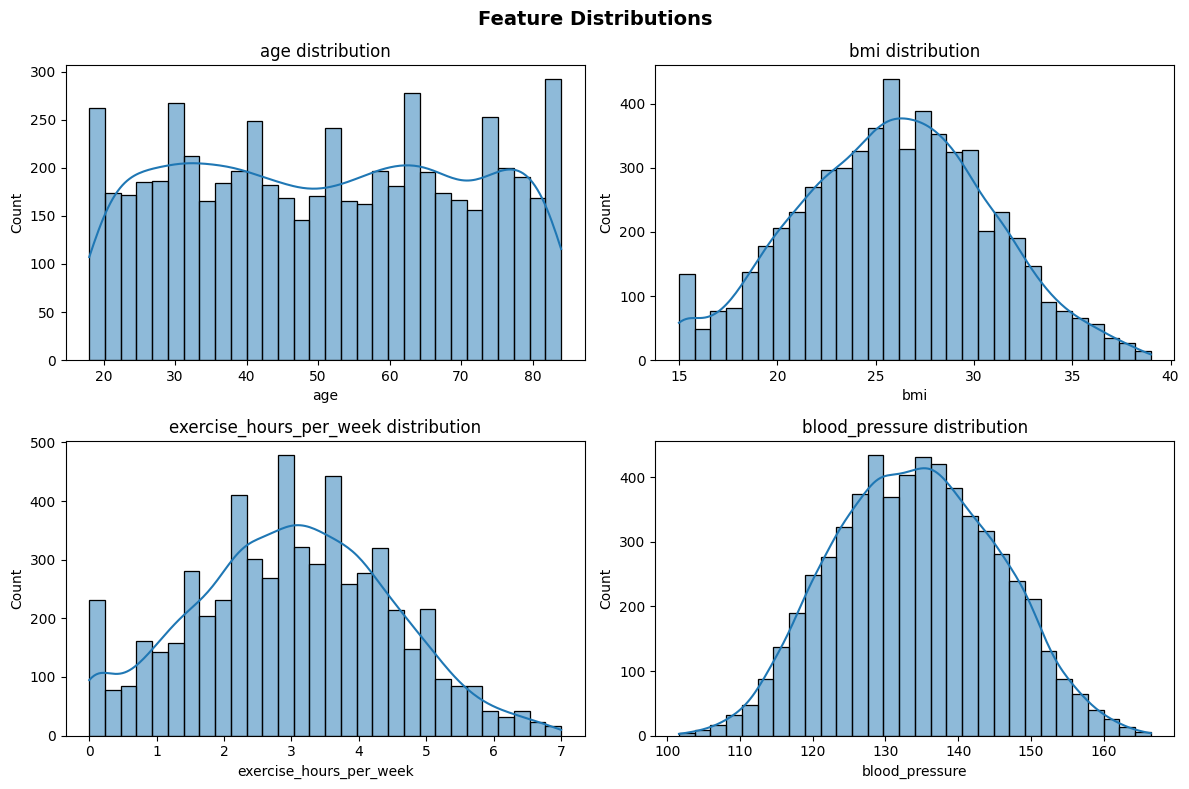

In [19]:
cols = ['age', 'bmi', 'exercise_hours_per_week', 'blood_pressure']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
fig.suptitle('Feature Distributions', fontsize=14, fontweight='bold')

for i, col in enumerate(cols):
    ax = axes[i//2, i%2]
    sns.histplot(_health_data[col], bins=30, kde=True, ax=ax)
    ax.set_title(f'{col} distribution')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')

plt.tight_layout()
fig.savefig('feature_distributions_after_preprocess.png', dpi=300, bbox_inches='tight')
plt.show()

<Axes: >

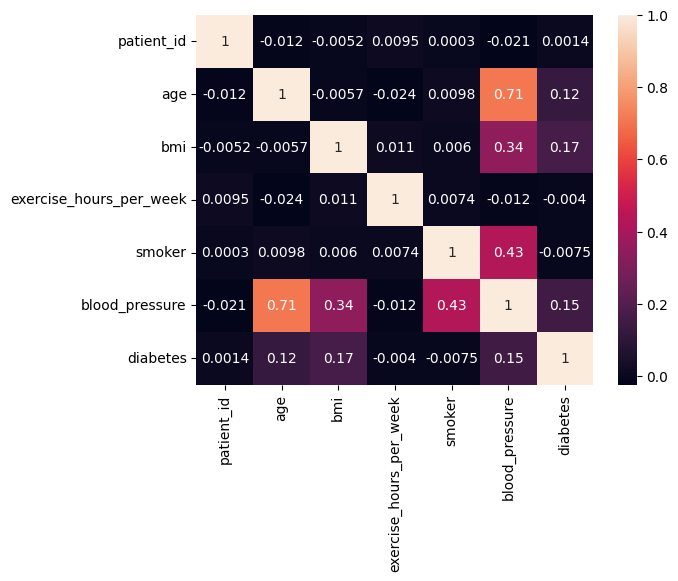

In [20]:
sns.heatmap(_health_data.corr(), annot=True)

VIF analysis reveals severe multicollinearity in the dataset blood_pressure (VIF: 86.76) and bmi (VIF: 41.11) are highly inflated, while age (VIF: 13.35) also exceeds the acceptable threshold of 10. Rather than dropping variables and risking loss of information, Principal Component Analysis (PCA) was applied to transform the correlated features into a set of orthogonal components. This approach effectively removes multicollinearity while preserving the maximum variance in the data, allowing the model to learn from all original features in a more stable and unbiased manner.

In [21]:
X = _health_data.drop(columns=['diabetes'])

vif = pd.DataFrame()
vif["feature"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif)

                   feature        VIF
0               patient_id   3.945785
1                      age  13.345488
2                      bmi  41.108692
3  exercise_hours_per_week   5.081438
4                   smoker   1.667423
5           blood_pressure  86.760435


In [22]:
_health_data = _health_data.drop(['patient_id','exercise_hours_per_week'],axis=1)
x = _health_data.drop(['diabetes'], axis=1)
y = _health_data['diabetes']

In [23]:
X = _health_data.drop(columns=['diabetes'])

vif = pd.DataFrame()
vif["feature"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]

print(vif)

          feature        VIF
0             age  12.995145
1             bmi  41.028380
2          smoker   1.649721
3  blood_pressure  74.283893


In [24]:
x.head()

,age,bmi,smoker,blood_pressure
0,31,18.3,0,119.1
1,44,26.3,0,120.5
2,43,24.2,0,130.3
3,32,25.0,0,119.5
4,28,22.1,1,127.4


In [25]:
y.head()

0    0
1    0
2    0
3    0
4    0
Name: diabetes, dtype: int64

### splitting the data into train and test sets

In [26]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42)

## Logistic Regression

In [27]:
y_train.value_counts()

diabetes
0    4341
1     413
Name: count, dtype: int64

In [28]:
y_test.value_counts()

diabetes
0    1071
1     118
Name: count, dtype: int64

StandardScaler was chosen over RobustScaler because the IQR-based outlier removal performed earlier had already eliminated extreme values in the feature columns, making the data approximately normal and free of influential outliers rendering RobustScaler's median/IQR-based scaling redundant; StandardScaler's mean-variance normalization is therefore the more appropriate and efficient choice for this cleaned dataset

In [29]:
_scaler = StandardScaler()

In [30]:
cols_to_scale = ['age', 'bmi', 'blood_pressure']

_x_train_scaled = x_train.copy()
_x_test_scaled = x_test.copy()

_x_train_scaled[cols_to_scale] = _scaler.fit_transform(x_train[cols_to_scale])
_x_test_scaled[cols_to_scale] = _scaler.transform(x_test[cols_to_scale])

In [31]:
pca_cols = ['age', 'bmi', 'blood_pressure']
cat_cols = ['smoker']

pca = PCA(n_components=0.95)
pca_train = pca.fit_transform(_x_train_scaled[pca_cols])
pca_test  = pca.transform(_x_test_scaled[pca_cols])

print(f"Components selected: {pca.n_components_}")
print(f"Variance explained: {np.cumsum(pca.explained_variance_ratio_).round(3)}")

pc_cols = [f'PC{i+1}' for i in range(pca.n_components_)]

x_train_final = pd.concat(
    [
        pd.DataFrame(pca_train, columns=pc_cols, index=x_train.index),
        x_train[cat_cols]
    ],
    axis=1
)

x_test_final = pd.concat(
    [
        pd.DataFrame(pca_test, columns=pc_cols, index=x_test.index),
        x_test[cat_cols]
    ],
    axis=1
)

Components selected: 3
Variance explained: [0.596 0.933 1.   ]


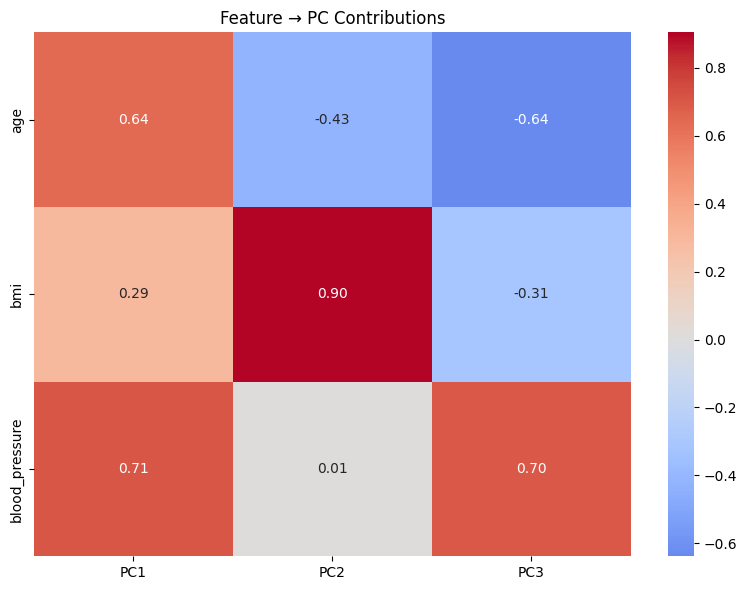

                     PC1       PC2       PC3
age             0.640824 -0.426660 -0.638205
bmi             0.292798  0.904330 -0.310574
blood_pressure  0.709658  0.012158  0.704442


In [32]:
loadings = pd.DataFrame(
    pca.components_.T,
    index=pca_cols,
    columns=[f'PC{i+1}' for i in range(pca.n_components_)]
)

plt.figure(figsize=(8,6))
sns.heatmap(loadings, annot=True, cmap='coolwarm', center=0, fmt='.2f')
plt.title('Feature → PC Contributions')
plt.tight_layout()
plt.savefig('pca_loadings_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print(loadings)

In [33]:
_x_train_scaled.head()
_x_test_scaled.head()

,age,bmi,smoker,blood_pressure
4813,1.011439,-1.180317,1,0.251001
2149,-0.669475,0.077242,1,-0.665214
1410,1.367996,0.242168,1,2.110118
5235,-0.669475,-0.850466,0,-1.109979
2854,0.247387,-2.252335,0,-0.558471


Logistic Regression was configured with class_weight='balanced' to automatically counteract the severe 9:1 class imbalance (seen in the diabetes distribution plot) by assigning higher penalty to misclassifying the minority diabetic class, ensuring the model doesn't simply predict non-diabetic for all samples.

In [34]:
from sklearn.metrics import classification_report, roc_auc_score

sm = SMOTE(random_state=42)
x_train_sm, y_train_sm = sm.fit_resample(x_train_final, y_train)

_ml_model = LogisticRegression(penalty='l1',solver='saga',max_iter=500,C=0.05, random_state=42)
_ml_model.fit(x_train_sm, y_train_sm)

_y_ml_preds  = _ml_model.predict(x_test_final)

In [35]:
print("Accuracy : ",round(accuracy_score(y_test, _y_ml_preds) * 100,2))

Accuracy :  65.01


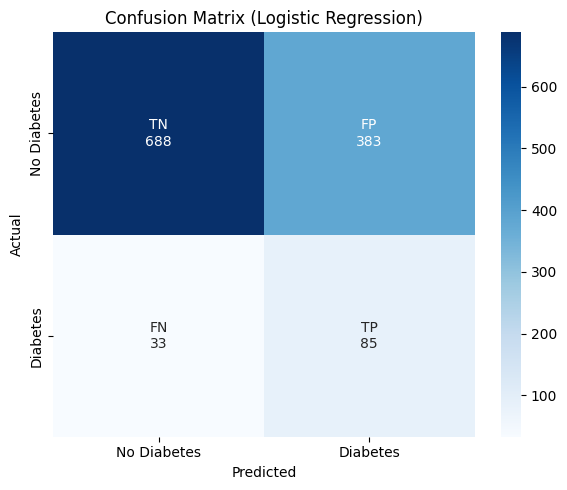

In [36]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

_cm = confusion_matrix(y_test, _y_ml_preds)

tn, fp, fn, tp = _cm.ravel()

labels = np.array([
    [f"TN\n{tn}", f"FP\n{fp}"],
    [f"FN\n{fn}", f"TP\n{tp}"]
])

plt.figure(figsize=(6,5))

sns.heatmap(
    _cm,
    annot=labels,
    fmt='',
    cmap='Blues',
    xticklabels=['No Diabetes','Diabetes'],
    yticklabels=['No Diabetes','Diabetes']
)

plt.title('Confusion Matrix (Logistic Regression)')
plt.xlabel('Predicted')
plt.ylabel('Actual')

plt.tight_layout()
plt.savefig('confusion_matrix_LR.png', dpi=300, bbox_inches='tight')

plt.show()

### PREDICTIONS

In [37]:
new_data = pd.DataFrame({
    'patient_id': [101,102,103,104,105,106,107,108,109,110],
    'age': [45,60,25,35,50,29,67,40,55,31],
    'bmi': [28.5,32.1,22.0,26.5,30.2,24.0,34.5,27.8,31.0,23.5],
    'exercise_hours_per_week': [3,1,5,4,2,6,0,3,1,5],
    'smoker': [0,0,0,1,1,0,1,0,1,0],
    'blood_pressure': [130,150,110,120,140,115,160,135,145,118]
})

num_cols = ['age', 'bmi', 'blood_pressure']
cat_cols = ['smoker']

X_new_num = new_data[num_cols]
X_new_cat = new_data[cat_cols]
X_new_scaled = _scaler.transform(X_new_num)

X_new_pca = pca.transform(X_new_scaled)

X_new_final = pd.concat(
    [
        pd.DataFrame(X_new_pca, columns=[f'PC{i+1}' for i in range(pca.n_components_)]),
        X_new_cat.reset_index(drop=True)
    ],
    axis=1
)

predictions = _ml_model.predict(X_new_final)
probabilities = _ml_model.predict_proba(X_new_final)[:, 1]

new_data['Prediction'] = predictions
new_data['Diabetes_Probability'] = probabilities

print(new_data)

   patient_id  age   bmi  exercise_hours_per_week  smoker  blood_pressure  \
0         101   45  28.5                        3       0             130   
1         102   60  32.1                        1       0             150   
2         103   25  22.0                        5       0             110   
3         104   35  26.5                        4       1             120   
4         105   50  30.2                        2       1             140   
5         106   29  24.0                        6       0             115   
6         107   67  34.5                        0       1             160   
7         108   40  27.8                        3       0             135   
8         109   55  31.0                        1       1             145   
9         110   31  23.5                        5       0             118   

   Prediction  Diabetes_Probability  
0           1              0.504684  
1           1              0.766535  
2           0              0.180114  


C:\Users\281770\AppData\Local\Programs\Python\Python310\lib\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


In [38]:
precision = precision_score(y_test, _y_ml_preds, average='macro')
recall = recall_score(y_test, _y_ml_preds, average='macro')
f1 = f1_score(y_test, _y_ml_preds, average='macro')

print("Precision Score:", round(precision, 3))
print("Recall Score:", round(recall, 3))
print("F1 Score:", round(f1, 3))

Precision Score: 0.568
Recall Score: 0.681
F1 Score: 0.529


In [39]:
print("\nClassification Report:\n")
print(classification_report(y_test, _y_ml_preds))


Classification Report:

              precision    recall  f1-score   support

           0       0.95      0.64      0.77      1071
           1       0.18      0.72      0.29       118

    accuracy                           0.65      1189
   macro avg       0.57      0.68      0.53      1189
weighted avg       0.88      0.65      0.72      1189



The absolute coefficients of the trained Logistic Regression model were extracted and ranked to assess feature importance since L1 regularization was applied, any feature with a coefficient of exactly zero was effectively eliminated by the model itself, with the remaining non-zero coefficients reflecting the true predictive weight each feature carries toward diabetes classification.

  Feature  Importance
0     PC1    0.522654
3  smoker    0.519823
1     PC2    0.416012
2     PC3    0.022096


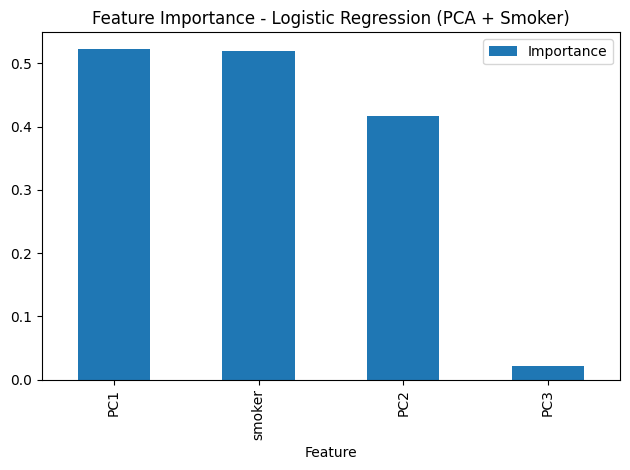

In [41]:
feature_names = pc_cols + ['smoker']

coefficients = pd.DataFrame({
    'Feature': feature_names,
    'Importance': abs(_ml_model.coef_[0])
}).sort_values('Importance', ascending=False)

print(coefficients)

coefficients.plot(kind='bar', x='Feature', y='Importance')
plt.title('Feature Importance - Logistic Regression (PCA + Smoker)')
plt.tight_layout()

plt.savefig('logreg_feature_importance.png', dpi=300, bbox_inches='tight')
plt.show()

### Balanced Logistic Regression Model Results

After applying class balancing, recall improves significantly. This means the model is better at identifying diabetic patients, though precision may decrease.

## Neural Network

We now use a Neural Network to capture more complex patterns in the data. The model consists of multiple layers with ReLU activation and a sigmoid output layer.

In [42]:
_health_data = pd.read_csv('./healthcare_dataset.csv')

In [43]:
_numeric_cols = ['age','bmi','exercise_hours_per_week','blood_pressure']

for col in _numeric_cols:
    if col == 'bmi':
        _health_data = _health_data[_health_data['bmi'] <= 39]
    else:
        _Q1 = _health_data[col].quantile(0.25)
        _Q3 = _health_data[col].quantile(0.75)
    
        _IQR = _Q3 -_Q1
        _low = _Q1 - 1.5*_IQR
        _high = _Q3 + 1.5 * _IQR
        _health_data = _health_data[(_health_data[col] >= _low) & (_health_data[col] <= _high)]
print(_health_data.shape)

    

(5943, 7)


In [44]:
_health_data = _health_data.drop(['patient_id','exercise_hours_per_week'], axis=1)
x = _health_data.drop(['diabetes'], axis=1)
y = _health_data['diabetes']


The dataset was split into three stratified subsets — training (68%), validation (15%), and test (20%) where stratify=y ensures the 9:1 diabetic-to-non-diabetic class ratio is preserved across all three splits, with the validation set carved from the training data specifically to monitor the neural network's generalization

With only 9% diabetic cases, an unstratified random split could by chance place very few or no diabetic samples in the validation or test set, making evaluation metrics unreliable stratify=y guarantees proportional class representation in every subset.

In [45]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state=42,stratify=y)
x_train, x_val, y_train, y_val = train_test_split(x_train, y_train, test_size=0.15, random_state=42,stratify=y_train)

In [46]:
_nn_scaler = StandardScaler()

cols_to_scale = ['age', 'bmi','blood_pressure']

_x_train_scaled = x_train.copy()
_x_val_scaled = x_val.copy()
_x_test_scaled = x_test.copy()

_x_train_scaled[cols_to_scale] = _nn_scaler.fit_transform(x_train[cols_to_scale])
_x_val_scaled[cols_to_scale] = _nn_scaler.transform(x_val[cols_to_scale])
_x_test_scaled[cols_to_scale] = _nn_scaler.transform(x_test[cols_to_scale])

_x_train_nn = _x_train_scaled.values
_x_val_nn = _x_val_scaled.values
_x_test_nn  = _x_test_scaled.values

In [47]:
_nn_model = keras.Sequential([
    layers.Input(shape=(_x_train_nn.shape[1],)),
    layers.Dense(64, activation='relu', kernel_regularizer=keras.regularizers.l2(0.005)),
    layers.Dropout(0.3),
    layers.Dense(32, activation='relu', kernel_regularizer=keras.regularizers.l2(0.005)),
    layers.Dropout(0.2),
    layers.Dense(16, activation='relu', kernel_regularizer=keras.regularizers.l2(0.005)),
    layers.Dropout(0.1),
    layers.Dense(1, activation='sigmoid')
])

_nn_model.summary()


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense (Dense)                        │ (None, 64)                  │             320 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout (Dropout)                    │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_1 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 16)                  │             528 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_2 (Dropout)                  │ (None, 16)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_3 (Dense)                      │ (None, 1)                   │              17 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 2,945 (11.50 KB)

 Trainable params: 2,945 (11.50 KB)

 Non-trainable params: 0 (0.00 B)

In [48]:
_nn_model.compile(
    optimizer=keras.optimizers.Adam(learning_rate=0.0005),
    loss='binary_crossentropy',
    metrics=['accuracy',keras.metrics.AUC(name='auc')]
)

In [49]:
_erly_stp = EarlyStopping(monitor='val_loss', patience=25,mode='min', restore_best_weights=True)

Epoch 1/300
64/64 ━━━━━━━━━━━━━━━━━━━━ 6s 21ms/step - accuracy: 0.3577 - auc: 0.5440 - loss: 1.0211 - val_accuracy: 0.5868 - val_auc: 0.7134 - val_loss: 1.0033 - learning_rate: 5.0000e-04
Epoch 2/300
64/64 ━━━━━━━━━━━━━━━━━━━━ 2s 10ms/step - accuracy: 0.5933 - auc: 0.6568 - loss: 0.9427 - val_accuracy: 0.6401 - val_auc: 0.7313 - val_loss: 0.9063 - learning_rate: 5.0000e-04
Epoch 3/300
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.6158 - auc: 0.6704 - loss: 0.8896 - val_accuracy: 0.6373 - val_auc: 0.7349 - val_loss: 0.8473 - learning_rate: 5.0000e-04
Epoch 4/300
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.6084 - auc: 0.6837 - loss: 0.8487 - val_accuracy: 0.6303 - val_auc: 0.7369 - val_loss: 0.8105 - learning_rate: 5.0000e-04
Epoch 5/300
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.6072 - auc: 0.6914 - loss: 0.8126 - val_accuracy: 0.6359 - val_auc: 0.7387 - val_loss: 0.7723 - learning_rate: 5.0000e-04
Epoch 6/300
64/64 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accura

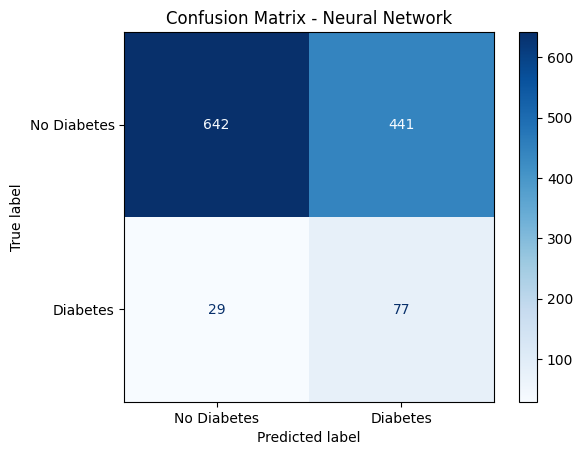

In [50]:
_class_weights = compute_class_weight('balanced', classes=np.unique(y_train), y=y_train)
_class_weight_dict = dict(enumerate(_class_weights))

_reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    factor=0.5,
    patience=10,
    min_lr=1e-6,
    verbose=1
)

history = _nn_model.fit(
    _x_train_nn, y_train,
    epochs=300,
    batch_size=64,
    validation_data=(_x_val_nn, y_val),
    class_weight=_class_weight_dict,
    callbacks=[_reduce_lr, _erly_stp]
)

_y_nn_preds = (_nn_model.predict(_x_test_nn) > 0.5).astype(int)

tn, fp, fn, tp = confusion_matrix(y_test, _y_nn_preds).ravel()
print(f"True Positives  (TP) : {tp}")
print(f"True Negatives  (TN) : {tn}")
print(f"False Positives (FP) : {fp}")
print(f"False Negatives (FN) : {fn}")
print("Accuracy  :", round(accuracy_score(y_test, _y_nn_preds) * 100, 2))
print("Precision :", round(precision_score(y_test, _y_nn_preds, average='macro'), 3))
print("Recall :", round(recall_score(y_test, _y_nn_preds, average='macro'), 3))
print("F1 Score :", round(f1_score(y_test, _y_nn_preds, average='macro'), 3))


cm = confusion_matrix(y_test, _y_nn_preds)
tn, fp, fn, tp = cm.ravel()

disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['No Diabetes', 'Diabetes'])
disp.plot(cmap='Blues')
plt.title('Confusion Matrix - Neural Network')
plt.savefig('confusion_matrix_nn.png', dpi=300, bbox_inches='tight')
plt.show()

In [51]:
new_data = pd.DataFrame({
    'patient_id': [201,202,203,204,205,206,207,208,209,210],
    'age': [42,58,24,36,49,30,65,41,53,28],
    'bmi': [27.5,33.2,21.5,25.8,29.9,23.5,35.1,28.2,30.5,22.8],
    'exercise_hours_per_week': [3,1,5,4,2,6,0,3,1,5],
    'smoker': [0,1,0,1,1,0,1,0,1,0],
    'blood_pressure': [128,148,108,118,138,112,162,132,144,116]
})

X_new = new_data.drop(['patient_id', 'exercise_hours_per_week'], axis=1)
X_new_scaled = X_new.copy()
X_new_scaled[cols_to_scale] = _nn_scaler.transform(X_new[cols_to_scale])

X_new_nn = X_new_scaled.values

probabilities = _nn_model.predict(X_new_nn).flatten()
predictions = (probabilities > 0.5).astype(int)
new_data['Prediction'] = predictions
new_data['Diabetes_Probability'] = probabilities

print(new_data)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
   patient_id  age   bmi  exercise_hours_per_week  smoker  blood_pressure  \
0         201   42  27.5                        3       0             128   
1         202   58  33.2                        1       1             148   
2         203   24  21.5                        5       0             108   
3         204   36  25.8                        4       1             118   
4         205   49  29.9                        2       1             138   
5         206   30  23.5                        6       0             112   
6         207   65  35.1                        0       1             162   
7         208   41  28.2                        3       0             132   
8         209   53  30.5                        1       1             144   
9         210   28  22.8                        5       0             116   

   Prediction  Diabetes_Probability  
0           0              0.461299  
1           1              0.669847  


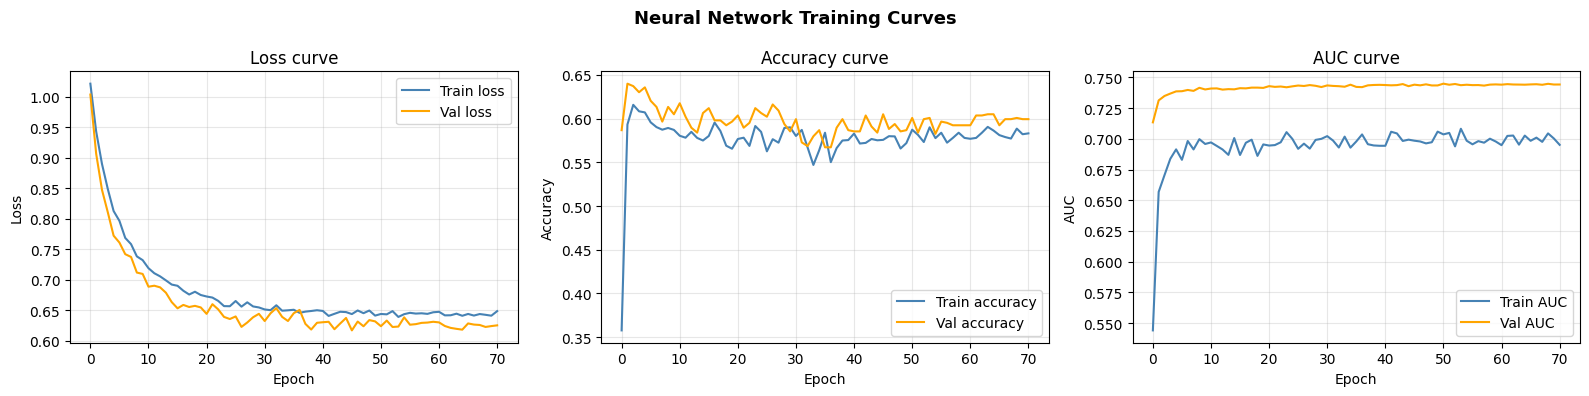

In [52]:
fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].plot(history.history['loss'],label='Train loss',color='steelblue')
axes[0].plot(history.history['val_loss'],label='Val loss',color='orange')
axes[0].set_title('Loss curve')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(history.history['accuracy'],label='Train accuracy',color='steelblue')
axes[1].plot(history.history['val_accuracy'],label='Val accuracy',color='orange')
axes[1].set_title('Accuracy curve')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('Accuracy')
axes[1].legend()
axes[1].grid(alpha=0.3)

axes[2].plot(history.history['auc'],label='Train AUC',color='steelblue')
axes[2].plot(history.history['val_auc'], label='Val AUC',color='orange')
axes[2].set_title('AUC curve')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('AUC')
axes[2].legend()
axes[2].grid(alpha=0.3)

plt.suptitle('Neural Network Training Curves',fontsize=13, fontweight='bold')
plt.tight_layout()

fig.savefig('nn_training_curves.png', dpi=300, bbox_inches='tight')

plt.show()

### Model Performance Analysis

After applying L2 regularisation, tuning dropout (0.1–0.4), and replacing SMOTE with class weighting, the neural network shows a clear reduction in overfitting. The training and validation loss curves converge smoothly and remain closely aligned throughout training, indicating that the model is no longer memorising the training data and has improved generalisation.

The validation AUC (0.74) consistently remains higher than the training AUC (0.69–0.70). This behaviour is expected under strong regularisation, where the model is slightly constrained and does not fully fit the training data, but generalises better to unseen data. The absence of divergence between training and validation curves further supports that overfitting has been effectively controlled.

Although the model demonstrates stable learning, both training and validation accuracy remain relatively modest (0.58–0.61). Given the class imbalance (approximately 9:1), accuracy is not a reliable metric in this context. Instead, AUC provides a more meaningful evaluation, indicating that the model has a reasonable ability to distinguish between classes.

Class weighting proved more effective than SMOTE for handling imbalance in this scenario. Rather than generating synthetic samples, class weighting adjusts the loss function to penalise misclassification of the minority class more heavily, resulting in improved generalisation without altering the underlying data distribution.

### Model Comparison Insights

Neural networks typically perform best on large datasets with complex, non-linear feature interactions. However, in this case, the dataset is relatively small and contains a limited number of original features, restricting the complexity of patterns the neural network can learn.

In contrast, Principal Component Analysis (PCA) and SMOTE was applied specifically to the Logistic Regression model to address multicollinearity and reduce feature redundancy and class balancing. By transforming the original correlated variables into a smaller set of orthogonal components, PCA allows Logistic Regression to operate in a more stable and efficient feature space.

As a result, the neural network despite careful regularisation does not significantly outperform Logistic Regression. The simpler model benefits from PCA-driven feature decorrelation, remains highly interpretable, and achieves comparable predictive performance with lower computational complexity.

### Conclusion

The combination of regularisation (L2 and dropout) and appropriate imbalance handling (class weighting) successfully stabilised the neural network and reduced overfitting. However, due to the limited size and complexity of the dataset, the neural network does not deliver substantial performance gains.

For this problem, AUC is the most reliable evaluation metric, and while the neural network achieves reasonable performance, it does not outperform Logistic Regression. With the application of PCA to mitigate multicollinearity, Logistic Regression remains a strong and interpretable baseline, offering comparable results with greater simplicity and efficiency.